# PENJELASAN SELURUH VARIABEL DATA

## 1. customerID
*  kode unik pelanggan (contoh: 7590-VHVEG)

## 2. gender
  * Male = laki-laki
  * Female = perempuan

## 3. SeniorCitizen (umur)
  * 0 = bukan lansia
  * 1 = lansia (biasanya umur ≥ 60–65)

## 4. Partner (pelanggan punya pasangan)
  * Yes = punya pasangan
  * No = tidak

## 5. Dependents (pakah punya tanggungan)
  * Yes = punya tanggungan
  * No = tidak

## 6. tenure (lama pelanggan berlangganan)
* angka (bulan)

## 7. PhoneService
* Isi: Yes / No

## 8. MultipleLines (apakah punya lebih dari 1 nomor telepon)
  * Yes
  * No
  * No phone service

## 9. InternetService (jenis layanan internet)
  * DSL
  * Fiber optic
  * No

## 10. OnlineSecurity
* Yes / No / No internet service

## 11. OnlineBackup
  * Yes / No / No internet service

## 12. DeviceProtection
  * Yes / No / No internet service

## 13. TechSupport
  * Yes / No / No internet service

## 14. StreamingTV
  * Yes / No / No internet service

## 15. StreamingMovies
  * Yes / No / No internet service

## 16. Contract (jenis kontrak pelanggan)
  * Month-to-month
  * One year
  * Two year
  * month-to-month = bulanan
  * 1 tahun / 2 tahun = kontrak panjang

## 17. PaperlessBilling
  * Yes = tagihan digital (tanpa kertas)
  * No = tagihan kertas

## 18. PaymentMethod (cara pembayaran)
  * Electronic check
  * Mailed check
  * Bank transfer (automatic)
  * Credit card (automatic)

## 19. MonthlyCharges
*  biaya yang dibayar tiap bulan

## 20. TotalCharges
* total biaya yang sudah dibayar selama jadi pelanggan

## 21.  Churn (TARGET)
  * Yes = berhenti langganan
  * No = masih pelanggan




# LATAR BELAKANG

Perusahaan Telekomunikasi XYZ merupakan salah satu penyedia layanan telekomunikasi yang memiliki basis pelanggan yang sangat luas. Dalam industri yang sangat kompetitif ini, perusahaan perlu memahami perilaku pelanggan untuk meningkatkan kualitas layanan, mempertahankan pelanggan (customer retention), serta mengurangi tingkat churn (pelanggan berhenti berlangganan).

Oleh karena itu, perusahaan melakukan analisis data pelanggan yang mencakup karakteristik demografis, jenis layanan yang digunakan, metode pembayaran, serta informasi penggunaan layanan bulanan.

Dengan adanya analisis ini, diharapkan perusahaan dapat mengidentifikasi faktor-faktor yang mempengaruhi keputusan pelanggan untuk tetap berlangganan atau berhenti menggunakan layanan


# PERNYATAAN MASALAH

Perusahaan Telekomunikasi XYZ memiliki fokus utama dalam meningkatkan retensi pelanggan dan menurunkan tingkat churn. Namun, perusahaan masih membutuhkan insight berbasis data untuk mendukung pengambilan keputusan strategis.

Sebagai seorang data analyst, beberapa permasalahan yang ingin dijawab adalah:

1. Bagaimana karakteristik pelanggan yang melakukan churn dibandingkan yang tidak churn?
2. Layanan apa saja yang paling mempengaruhi keputusan pelanggan untuk berhenti berlangganan?
3. Bagaimana pengaruh biaya bulanan (MonthlyCharges) dan total biaya (TotalCharges) terhadap churn pelanggan?
4. Bagaimana distribusi penggunaan layanan berdasarkan tipe kontrak pelanggan?


# DATA

Untuk menjawab permasalahan tersebut, digunakan dataset pelanggan telekomunikasi yang berisi informasi lengkap mengenai pelanggan, layanan yang digunakan, serta status churn.

# Import Library

In [244]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [245]:
data = pd.read_excel("Telco-Customer.xlsx")

display(data.head(),data.tail())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


# Cek Dimensi

In [246]:
print("Jumlah baris dan kolom:", data.shape)

Jumlah baris dan kolom: (7043, 21)


Dataset memiliki (sesuai 7043 baris dan 21 kolom) yang terdiri dari berbagai variabel pelanggan.


# Cek Info Data

In [247]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Dataset ini terdiri dari 7.043 observasi dan 21 variabel yang berisi data pelanggan layanan telekomunikasi, di mana sebagian besar variabel bertipe kategori (object), serta terdapat beberapa variabel numerik seperti SeniorCitizen, tenure, dan MonthlyCharges. Namun, terdapat sedikit data yang hilang pada MonthlyCharges dan TotalCharges, serta TotalCharges masih bertipe object sehingga perlu dikonversi ke numerik sebelum analisis. Secara umum, dataset ini digunakan untuk menganalisis perilaku pelanggan dan memprediksi churn atau keputusan pelanggan untuk berhenti berlangganan.


# Cek Missing Value

In [248]:
print(data.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges      24
TotalCharges        14
Churn                0
dtype: int64


Berdasarkan pengecekan missing value, hampir semua variabel tidak memiliki data yang hilang (0 missing), kecuali pada variabel MonthlyCharges terdapat 24 data yang kosong dan TotalCharges terdapat 14 data yang kosong.

# Cleaning Nama Kolom

In [249]:
data.columns = data.columns.str.strip().str.replace(" ", "")
print(data.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


# Perbaiki Kolom TotalCharges

In [250]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

untuk mengubah tipe data kolom TotalCharges dari string (object) menjadi numerik (float)

# Cek Dulu Tipe Data

In [251]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Cek Normal atau Tidak

In [252]:
from scipy.stats import shapiro

stat, p = shapiro(data['MonthlyCharges'].dropna())

if p > 0.05:
    print("Normal → pakai mean")
else:
    print("Tidak normal → pakai median")

Tidak normal → pakai median


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7019.
  res = hypotest_fun_out(*samples, **kwds)


# Imputasi Missing Value

In [253]:
data['MonthlyCharges'] = data['MonthlyCharges'].fillna(
    data['MonthlyCharges'].median()
)

In [254]:
data['TotalCharges'] = data['TotalCharges'].fillna(
    data['TotalCharges'].median()
)

karena didak normal gunakan median

# Cek Missing vakue Lagi

In [255]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


# Cek Duplikasi

In [256]:
data.duplicated().sum()

np.int64(0)

# Cek Nilai Unik (Data Understanding)

In [257]:
for col in data.columns:
    print(f"\n{col}: {data[col].unique()}")


customerID: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender: ['Female' 'Male']

SeniorCitizen: [0 1]

Partner: ['Yes' 'No']

Dependents: ['No' 'Yes']

tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]

PhoneService: ['No' 'Yes']

MultipleLines: ['No phone service' 'No' 'Yes']

InternetService: ['DSL' 'Fiber optic' 'No']

OnlineSecurity: ['No' 'Yes' 'No internet service']

OnlineBackup: ['Yes' 'No' 'No internet service']

DeviceProtection: ['No' 'Yes' 'No internet service']

TechSupport: ['No' 'Yes' 'No internet service']

StreamingTV: ['No' 'Yes' 'No internet service']

StreamingMovies: ['No' 'Yes' 'No internet service']

Contract: ['Month-to-month' 'One year' 'Two year']

PaperlessBilling: ['Yes' 'No']

PaymentMethod: ['Electronic check' 'Mailed check' 'Bank tr

# Statistika Deskriptif

In [258]:
data[['MonthlyCharges','TotalCharges']].describe()

,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000
mean,64.772767,2279.000185
std,30.032364,2262.212820
min,18.250000,18.800000
25%,35.675000,403.250000
50%,70.350000,1397.100000
75%,89.850000,3777.575000
max,118.750000,8684.800000


# ANALISIS

# 1. Karakteristik pelanggan churn vs tidak churn

In [259]:
# cek distribusi churn
print(data['Churn'].value_counts())
print(data['Churn'].value_counts(normalize=True) * 100)

# ringkasan statistik numerik berdasarkan churn
data.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


tenure                                                     \
        count       mean        std  min   25%   50%   75%   max   
Churn                                                              
No     5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0   
Yes    1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0   

      MonthlyCharges             ...                TotalCharges               \
               count       mean  ...    75%     max        count         mean   
Churn                            ...                                            
No            5174.0  61.295023  ...  88.05  118.75       5174.0  2548.438500   
Yes           1869.0  74.400294  ...  94.20  118.35       1869.0  1533.107277   

                                                              
               std    min    25%      50%       75%      max  
Churn                                                         
No     2324.361107  18.80  581.7  1672.35  4243.775  8672.45  
Yes    1890.301047  18.85  134.7   706.85  2331.300  8684.80  

[2 rows x 24 columns]

Hasil analisis menunjukkan bahwa data tidak seimbang, di mana 73,46% pelanggan tidak churn dan 26,54% pelanggan churn. Pelanggan yang churn cenderung memiliki masa berlangganan (tenure) lebih pendek dan biaya bulanan (MonthlyCharges) lebih tinggi dibandingkan pelanggan yang tidak churn, sedangkan TotalCharges pada pelanggan churn lebih rendah karena durasi berlangganan yang lebih singkat. Hal ini mengindikasikan bahwa lama berlangganan dan besarnya biaya bulanan berpengaruh terhadap kemungkinan pelanggan untuk berhenti berlangganan.

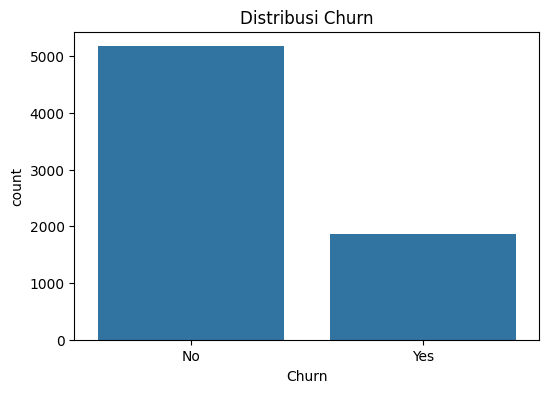

In [260]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=data)
plt.title("Distribusi Churn")
plt.show()

# 2. Layanan yang Mempengaruhi Churn

In [261]:
service_cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in service_cols:
    print("\n", col)
    print(pd.crosstab(data[col], data['Churn'], normalize='index') * 100)


 PhoneService
Churn                No        Yes
PhoneService                      
No            75.073314  24.926686
Yes           73.290363  26.709637

 MultipleLines
Churn                    No        Yes
MultipleLines                         
No                74.955752  25.044248
No phone service  75.073314  24.926686
Yes               71.390104  28.609896

 InternetService
Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980

 OnlineSecurity
Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194

 OnlineBackup
Churn                       No        Yes
OnlineBackup                             
No                   60.071244  39.928756
No internet service  92.595020   7.404980
Yes             

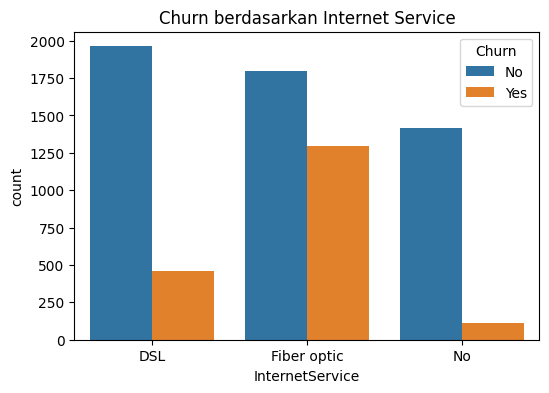

In [262]:
plt.figure(figsize=(6,4))
sns.countplot(x='InternetService', hue='Churn', data=data)
plt.title("Churn berdasarkan Internet Service")
plt.show()

Hasil ini menunjukkan bahwa churn pelanggan berbeda berdasarkan jenis layanan yang digunakan, terutama layanan internet. Pelanggan pengguna fiber optic memiliki tingkat churn paling tinggi (41,89%), disusul DSL (18,96%), sedangkan yang tidak menggunakan internet paling rendah (7,40%). Selain itu, pelanggan yang tidak memiliki layanan tambahan seperti Online Security, Tech Support, Online Backup, dan Device Protection cenderung lebih banyak melakukan churn dibandingkan yang menggunakan layanan tersebut. Sementara itu, layanan seperti PhoneService, MultipleLines, dan layanan streaming tidak menunjukkan perbedaan yang terlalu besar terhadap churn. Secara umum, pelanggan tanpa layanan tambahan dan pengguna fiber optic lebih berisiko untuk berhenti berlangganan.

# 3. Pengaruh MonthlyCharges & TotalCharges terhadap churn

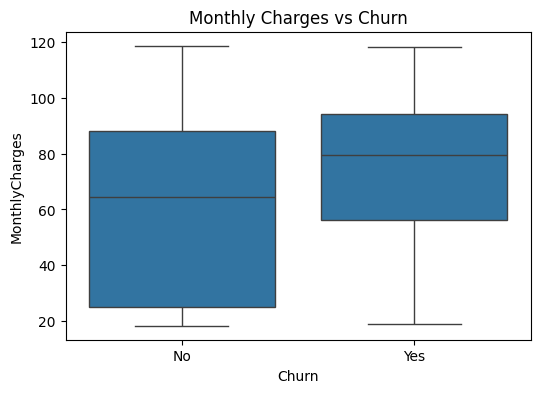

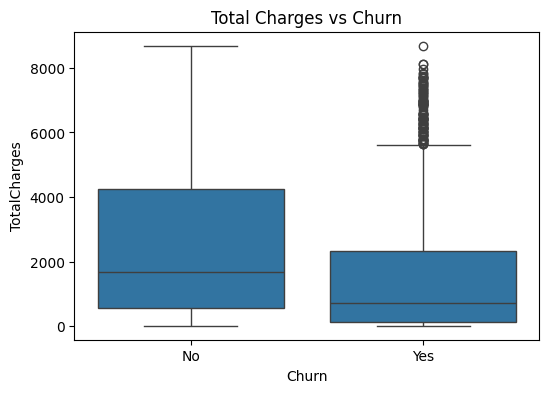

In [263]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=data)
plt.title("Monthly Charges vs Churn")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='TotalCharges', data=data)
plt.title("Total Charges vs Churn")
plt.show()


Boxplot tersebut menunjukkan bahwa pelanggan yang melakukan churn (*Yes*) cenderung memiliki **MonthlyCharges lebih tinggi** dibandingkan yang tidak churn (*No*), terlihat dari median yang lebih besar. Sebaliknya, pada **TotalCharges**, pelanggan yang tidak churn memiliki nilai yang lebih tinggi karena mereka berlangganan lebih lama, sedangkan pelanggan churn memiliki total biaya lebih rendah. Selain itu, terdapat beberapa **outlier** pada pelanggan churn untuk TotalCharges, namun secara umum pola ini menegaskan bahwa biaya bulanan yang tinggi dan durasi berlangganan yang lebih singkat berkaitan dengan kemungkinan churn.


# Statistik Tambahan

In [264]:
data.groupby('Churn')[['MonthlyCharges','TotalCharges']].mean()

,MonthlyCharges,TotalCharges
Churn,,
No,61.295023,2548.438500
Yes,74.400294,1533.107277


Hasil ini menunjukkan bahwa pelanggan yang churn memiliki MonthlyCharges lebih tinggi (74,40) dibandingkan yang tidak churn (61,29), yang berarti biaya bulanan yang lebih mahal cenderung meningkatkan kemungkinan pelanggan berhenti berlangganan. Namun, TotalCharges pada pelanggan churn lebih rendah (1533,11) dibandingkan yang tidak churn (2548,44) karena pelanggan yang churn biasanya memiliki masa berlangganan yang lebih singkat.

# 4. Distribusi berdasarkan Contract

In [265]:
print(data['Contract'].value_counts())

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64


Hasil ini menunjukkan bahwa sebagian besar pelanggan menggunakan kontrak Month-to-month (3875 pelanggan), diikuti Two year (1695) dan One year (1473). Hal ini mengindikasikan bahwa pelanggan dengan kontrak jangka pendek lebih dominan, yang biasanya juga lebih rentan untuk melakukan churn dibandingkan kontrak jangka panjang

# Layanan Tambah contract (lebih dalam)

In [266]:
data.groupby(['Contract','Churn']).size().unstack()

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


Hasil ini menunjukkan bahwa pelanggan dengan kontrak Month-to-month memiliki tingkat churn paling tinggi (1655 pelanggan), sedangkan One year dan Two year jauh lebih rendah masing-masing hanya 166 dan 48 pelanggan yang churn. Sebaliknya, pelanggan dengan kontrak jangka panjang lebih banyak bertahan (tidak churn), terutama pada kontrak Two year. Hal ini menunjukkan bahwa semakin panjang durasi kontrak, semakin kecil kemungkinan pelanggan untuk berhenti berlangganan.

# Visualisasi churn vs contract

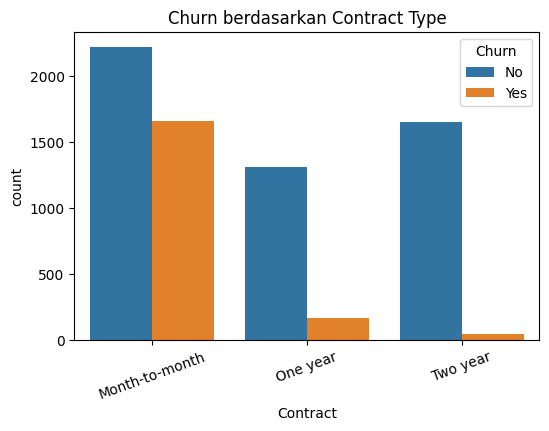

In [267]:


plt.figure(figsize=(6,4))
sns.countplot(x='Contract', hue='Churn', data=data)
plt.title("Churn berdasarkan Contract Type")
plt.xticks(rotation=20)
plt.show()


# Normalisasi Nilai Layanan (Service Cleaning)

In [268]:
service_cols = [
    'MultipleLines','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport',
    'StreamingTV','StreamingMovies'
]

for col in service_cols:
    data[col] = data[col].replace({
        'No internet service': 'No',
        'No phone service': 'No'
    })

Agar data konsisten → hanya punya 2 kategori: Yes / No (tidak bercampur banyak label)

# Normalisasi Nilai Layanan (Service Cleaning)

In [269]:
yes_no_cols = [
    'gender','Partner','Dependents','PhoneService',
    'PaperlessBilling'
] + service_cols

for col in yes_no_cols:
    data[col] = data[col].replace({
        'Yes': 1,
        'No': 0,
        'Male': 1,
        'Female': 0
    })

/tmp/ipykernel_5159/778499710.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col] = data[col].replace({


# Encoding Target (Churn)

In [270]:
data['Churn'] = data['Churn'].map({'Yes':1, 'No':0})

Model hanya bisa membaca angka wajib diubah

# Mengubah Tipe Data ke Numerik

In [271]:
data[yes_no_cols] = data[yes_no_cols].apply(pd.to_numeric)

Memastikan semua kolom sudah bertipe integer / numeric

# One Hot Encoding (Kategori Multi Kelas)

In [272]:
data = pd.get_dummies(data, columns=[
    'InternetService','Contract','PaymentMethod'
], drop_first=True)


Agar model bisa membaca kategori lebih dari 2 kelas

# Menghapus Kolom yang Tidak Digunakan

In [273]:
data = data.drop('customerID', axis=1)


# Membuat Variabel Baru (Total Services)

In [274]:
data['TotalServices'] = data[service_cols].sum(axis=1)


Menjumlahkan semua layanan yang digunakan pelanggan emakin banyak layanan biasanya lebih loyal

# Standarisasi Data Numerik (Scaling)

In [275]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['tenure','MonthlyCharges','TotalCharges','TotalServices']

data[num_cols] = scaler.fit_transform(data[num_cols])


Mengubah data jadi skala standar:

mean = 0
std = 1

Makanya muncul nilai minus (-)

In [276]:
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   float64
 5   PhoneService                           7043 non-null   int64  
 6   MultipleLines                          7043 non-null   int64  
 7   OnlineSecurity                         7043 non-null   int64  
 8   OnlineBackup                           7043 non-null   int64  
 9   DeviceProtection                       7043 non-null   int64  
 10  TechSupport                            7043 non-null   int64  
 11  Stre

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TotalServices
0,0,0,1,0,-1.277445,0,0,0,1,0,...,-0.994296,0,False,False,False,False,False,True,False,-0.713676
1,1,0,0,0,0.066327,1,0,1,0,1,...,-0.172189,0,False,False,True,False,False,False,True,-0.224772
2,1,0,0,0,-1.236724,1,0,1,1,0,...,-0.959682,1,False,False,False,False,False,False,True,-0.224772
3,1,0,0,0,0.514251,0,0,1,0,1,...,-0.193740,0,False,False,True,False,False,False,False,0.264131
4,0,0,0,0,-1.236724,1,0,0,0,0,...,-0.940451,1,True,False,False,False,False,True,False,-1.202579


Dataset ini merupakan hasil akhir preprocessing yang terdiri dari 7.043 data dan 25 variabel yang seluruhnya sudah dalam bentuk numerik sehingga siap digunakan untuk pemodelan machine learning. Variabel kategorik seperti *gender, Partner, Dependents,* dan layanan lainnya telah diubah menjadi biner (0 dan 1), sedangkan variabel seperti *InternetService, Contract,* dan *PaymentMethod* telah diubah menjadi beberapa kolom dummy (True/False) melalui one-hot encoding. Selain itu, variabel numerik seperti *tenure, MonthlyCharges, TotalCharges,* dan *TotalServices* telah dinormalisasi sehingga memiliki skala yang seragam. Variabel *Churn* digunakan sebagai target (0 = tidak churn, 1 = churn). Secara keseluruhan, data ini sudah bersih, terstruktur, dan siap digunakan untuk analisis maupun pembuatan model prediksi churn.
